# 02. Клиентская аналитика — этапы 3–4

**Бизнес-вопрос:** какие группы клиентов выбрать для кампании повторных покупок?
Ноутбук включает SQL-динамику, когорты, повторную покупку за 30 дней, RFM,
концентрацию продаж и проверки чувствительности.

Окно: **01.12.2010–30.11.2011**, все страны; срез — 01.12.2011.
Продажи — положительные товарные продажи до вычета отмен. Источник и правила
подготовки — в первом ноутбуке и reports/data_quality.md. Запускайте ячейки по порядку.


In [1]:
from pathlib import Path
from contextlib import closing
import json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'docs/01_project_brief.md').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Откройте ноутбук внутри распакованного проекта.')
DB = ROOT / 'data/processed/retail.sqlite'
if not DB.is_file():
    raise FileNotFoundError('Сначала выполните 01_data_preparation.ipynb.')
TABLES = ROOT / 'reports/tables'
FIGURES = ROOT / 'reports/figures'
for folder in [TABLES, FIGURES]:
    folder.mkdir(parents=True, exist_ok=True)
quality = json.loads((ROOT / 'reports/data_quality.json').read_text())

def query_file(name):
    # mode=ro: аналитический ноутбук не меняет подготовленную базу.
    with closing(sqlite3.connect(DB.as_uri() + '?mode=ro', uri=True)) as conn:
        return pd.read_sql_query((ROOT / 'sql' / name).read_text(), conn)

print('Окно:', quality['analysis_start'], '—', quality['analysis_end_exclusive'], '(исключено)')


Окно: 2010-12-01 — 2011-12-01 (исключено)


## 1. SQL-запросы и определения метрик

- `02_monthly_metrics.sql`: GROUP BY для заказов и сумм, CTE для промежуточных
  таблиц, LAG для предыдущего месяца. Средний чек = продажи / заказы.
- `03_customer_metrics.sql`: одна строка на известного клиента, первая/последняя
  покупка, число заказов, активных месяцев и сумма за окно.
- `04_customer_monthly.sql`: сначала одна строка на клиента в месяце, затем
  агрегация по месяцу. Соединение с первой покупкой не размножает строки.

Впервые наблюдаемые клиенты — те, чей первый наблюдаемый месяц совпал с текущим.
Ранее наблюдаемые — активные в текущем месяце с первой покупкой в предыдущем
месяце или раньше. Все покупки клиента в его первом месяце входят в сумму первой
группы, в том числе второй заказ в том же месяце. Это не показатели retention.
В первом месяце выгрузки все клиенты впервые наблюдаемые по определению.


In [2]:
monthly = query_file('02_monthly_metrics.sql')
customers = query_file('03_customer_metrics.sql')
customer_monthly = query_file('04_customer_monthly.sql')
with closing(sqlite3.connect(DB.as_uri() + '?mode=ro', uri=True)) as conn:
    orders = pd.read_sql_query('SELECT * FROM orders ORDER BY invoice_no', conn,
                               parse_dates=['order_date'])
orders['month'] = orders['order_date'].dt.strftime('%Y-%m')
known = orders.loc[orders['customer_id'].notna()].copy()
print(monthly[['month', 'orders', 'gross_sales_gbp', 'aov_gbp',
               'sales_mom_pct', 'orders_mom_pct', 'aov_mom_pct']].round(2).to_string(index=False))


  month  orders  gross_sales_gbp  aov_gbp  sales_mom_pct  orders_mom_pct  aov_mom_pct
2010-12    1550        777931.77   501.89            NaN             NaN          NaN
2011-01    1081        671933.19   621.58         -13.63          -30.26        23.85
2011-02    1093        508886.20   465.59         -24.27            1.11       -25.10
2011-03    1440        691257.61   480.04          35.84           31.75         3.10
2011-04    1235        516218.12   417.99         -25.32          -14.24       -12.93
2011-05    1668        741192.41   444.36          43.58           35.06         6.31
2011-06    1525        738751.87   484.43          -0.33           -8.57         9.02
2011-07    1452        689364.41   474.77          -6.69           -4.79        -1.99
2011-08    1339        725513.50   541.83           5.24           -7.78        14.13
2011-09    1818       1030475.36   566.82          42.03           35.77         4.61
2011-10    2005       1106669.82   551.96           7.

## 2. Проверки на независимых агрегациях pandas

Проверяем все месяцы и каждого клиента. Число активных клиентов в месяцах
нельзя складывать в уникальных клиентов за год: один покупатель активен в нескольких
месяцах. Число впервые наблюдаемых клиентов, наоборот, должно суммироваться
в число уникальных клиентов окна. Изменение для первого месяца остаётся пустым.


In [3]:
expected_months = pd.period_range('2010-12', '2011-11', freq='M').astype(str).tolist()
assert monthly['month'].tolist() == expected_months
assert customer_monthly['month'].tolist() == expected_months
assert monthly['month'].is_unique and customers['customer_id'].is_unique
assert customers['customer_id'].notna().all()

pm = orders.groupby('month').agg(orders=('invoice_no', 'size'),
    gross_sales_gbp=('gross_sales_gbp', 'sum'), units=('units', 'sum'),
    active_identified_customers=('customer_id', 'nunique')).reset_index()
for col in ['orders', 'units', 'active_identified_customers']:
    assert np.array_equal(monthly[col], pm[col])
assert np.allclose(monthly['gross_sales_gbp'], pm['gross_sales_gbp'], rtol=0, atol=0.01)
assert np.allclose(monthly['aov_gbp'], pm['gross_sales_gbp'] / pm['orders'], rtol=0, atol=0.01)
assert np.allclose(monthly['units_per_order'], pm['units'] / pm['orders'], rtol=0, atol=1e-9)
for value, change in [('gross_sales_gbp', 'sales_mom_pct'), ('orders', 'orders_mom_pct'), ('aov_gbp', 'aov_mom_pct')]:
    expected = 100 * monthly[value].pct_change()
    assert np.allclose(monthly[change], expected, rtol=0, atol=1e-9, equal_nan=True)
    assert pd.isna(monthly.loc[0, change])

pc = known.groupby('customer_id').agg(first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max'), orders=('invoice_no', 'size'),
    gross_sales_gbp=('gross_sales_gbp', 'sum'), units=('units', 'sum'),
    active_months=('month', 'nunique')).sort_index()
sc = customers.set_index('customer_id').sort_index()
assert sc.index.tolist() == pc.index.tolist()
for col in ['orders', 'units', 'active_months']:
    assert np.array_equal(sc[col], pc[col])
for col in ['first_order_date', 'last_order_date']:
    assert np.array_equal(pd.to_datetime(sc[col]).to_numpy(), pc[col].to_numpy())
assert np.allclose(sc['gross_sales_gbp'], pc['gross_sales_gbp'], rtol=0, atol=0.01)

first_month = known.groupby('customer_id')['month'].transform('min')
known['first_observed_month'] = first_month
known['first_month_group'] = known['month'].eq(first_month)
known['first_month_sales_gbp'] = known['gross_sales_gbp'].where(known['first_month_group'], 0)
known['previous_months_sales_gbp'] = known['gross_sales_gbp'].where(~known['first_month_group'], 0)
pmix = known.groupby('month').agg(first_month_sales_gbp=('first_month_sales_gbp', 'sum'),
    previous_months_customers_sales_gbp=('previous_months_sales_gbp', 'sum'))
cm = customer_monthly.set_index('month')
for col in pmix.columns:
    assert np.allclose(cm[col], pmix[col], rtol=0, atol=0.01)
for group, col in [(True, 'first_observed_customers'), (False, 'previously_observed_customers')]:
    counts = known.loc[known['first_month_group'].eq(group)].groupby('month')['customer_id'].nunique()
    assert np.array_equal(cm[col], counts.reindex(expected_months, fill_value=0))
assert np.array_equal(cm['first_observed_customers'] + cm['previously_observed_customers'], cm['active_identified_customers'])
assert np.array_equal(cm['active_identified_customers'], monthly['active_identified_customers'])
assert np.array_equal(cm['identified_orders'], monthly['identified_orders'])
assert np.allclose(cm['identified_sales_gbp'], monthly['identified_sales_gbp'], rtol=0, atol=0.01)
assert customer_monthly['first_observed_customers'].sum() == len(customers) == quality['identified_customers']
assert orders['invoice_no'].is_unique
assert monthly['orders'].sum() == quality['orders']
assert np.isclose(monthly['gross_sales_gbp'].sum(), quality['gross_sales_gbp'], rtol=0, atol=0.01)
assert customers['orders'].sum() == quality['identified_orders']
assert np.isclose(customers['gross_sales_gbp'].sum(), quality['identified_gross_sales_gbp'], rtol=0, atol=0.01)
print('Проверены 12 месяцев, каждый клиент, состав групп и контрольные суммы этапа 2.')


Проверены 12 месяцев, каждый клиент, состав групп и контрольные суммы этапа 2.


## 3. Таблицы и параметры графиков

Медиану чека вычисляем в pandas: встроенной функции MEDIAN в SQLite нет.
Она дополняет AOV, чувствительный к крупным оптовым счетам. Сумма средних чеков
по месяцам не является средним чеком за всё окно: нужен взвешенный расчёт через
общую сумму и общее количество заказов.


In [4]:
distribution = orders.groupby('month')['gross_sales_gbp'].agg(
    median_order_gbp='median', p90_order_gbp=lambda s: s.quantile(0.9), max_order_gbp='max').reset_index()
monthly = monthly.merge(distribution, on='month', validate='one_to_one')
customer_monthly['previously_observed_customers_pct'] = (
    100 * customer_monthly['previously_observed_customers'] / customer_monthly['active_identified_customers'])
customer_monthly['previous_months_customers_sales_pct'] = (
    100 * customer_monthly['previous_months_customers_sales_gbp'] / customer_monthly['identified_sales_gbp'])
for name, frame in [('monthly_metrics', monthly), ('customer_metrics', customers),
                    ('customer_monthly', customer_monthly), ('order_value_distribution', distribution)]:
    frame.to_csv(TABLES / f'{name}.csv', index=False)

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'figure.facecolor': 'white', 'axes.facecolor': 'white'})
BLUE, TEAL, GRAY = '#2563EB', '#0F766E', '#64748B'
x = np.arange(len(monthly))
labels = ['Дек 10', 'Янв 11', 'Фев 11', 'Мар 11', 'Апр 11', 'Май 11',
          'Июн 11', 'Июл 11', 'Авг 11', 'Сен 11', 'Окт 11', 'Ноя 11']

def style_axis(ax, ylabel):
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, labels)
    ax.grid(axis='y', alpha=0.18)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)

def save_figure(fig, name):
    global latest_figure
    latest_figure = FIGURES / f'{name}.png'
    fig.savefig(latest_figure, dpi=170, bbox_inches='tight', facecolor='white')
    fig.savefig(FIGURES / f'{name}.svg', bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print('Сохранён график:', latest_figure.name)


## 4. Продажи и число заказов

Смотрим на оба компонента: продажи = заказы × средний чек. Две панели используют
разные единицы и отдельные оси. Все месяцы полные. Пик в наблюдаемом окне не
доказывает устойчивую сезонность: нескольких полных лет в данных нет.


Сохранён график: 01_monthly_sales_orders.png


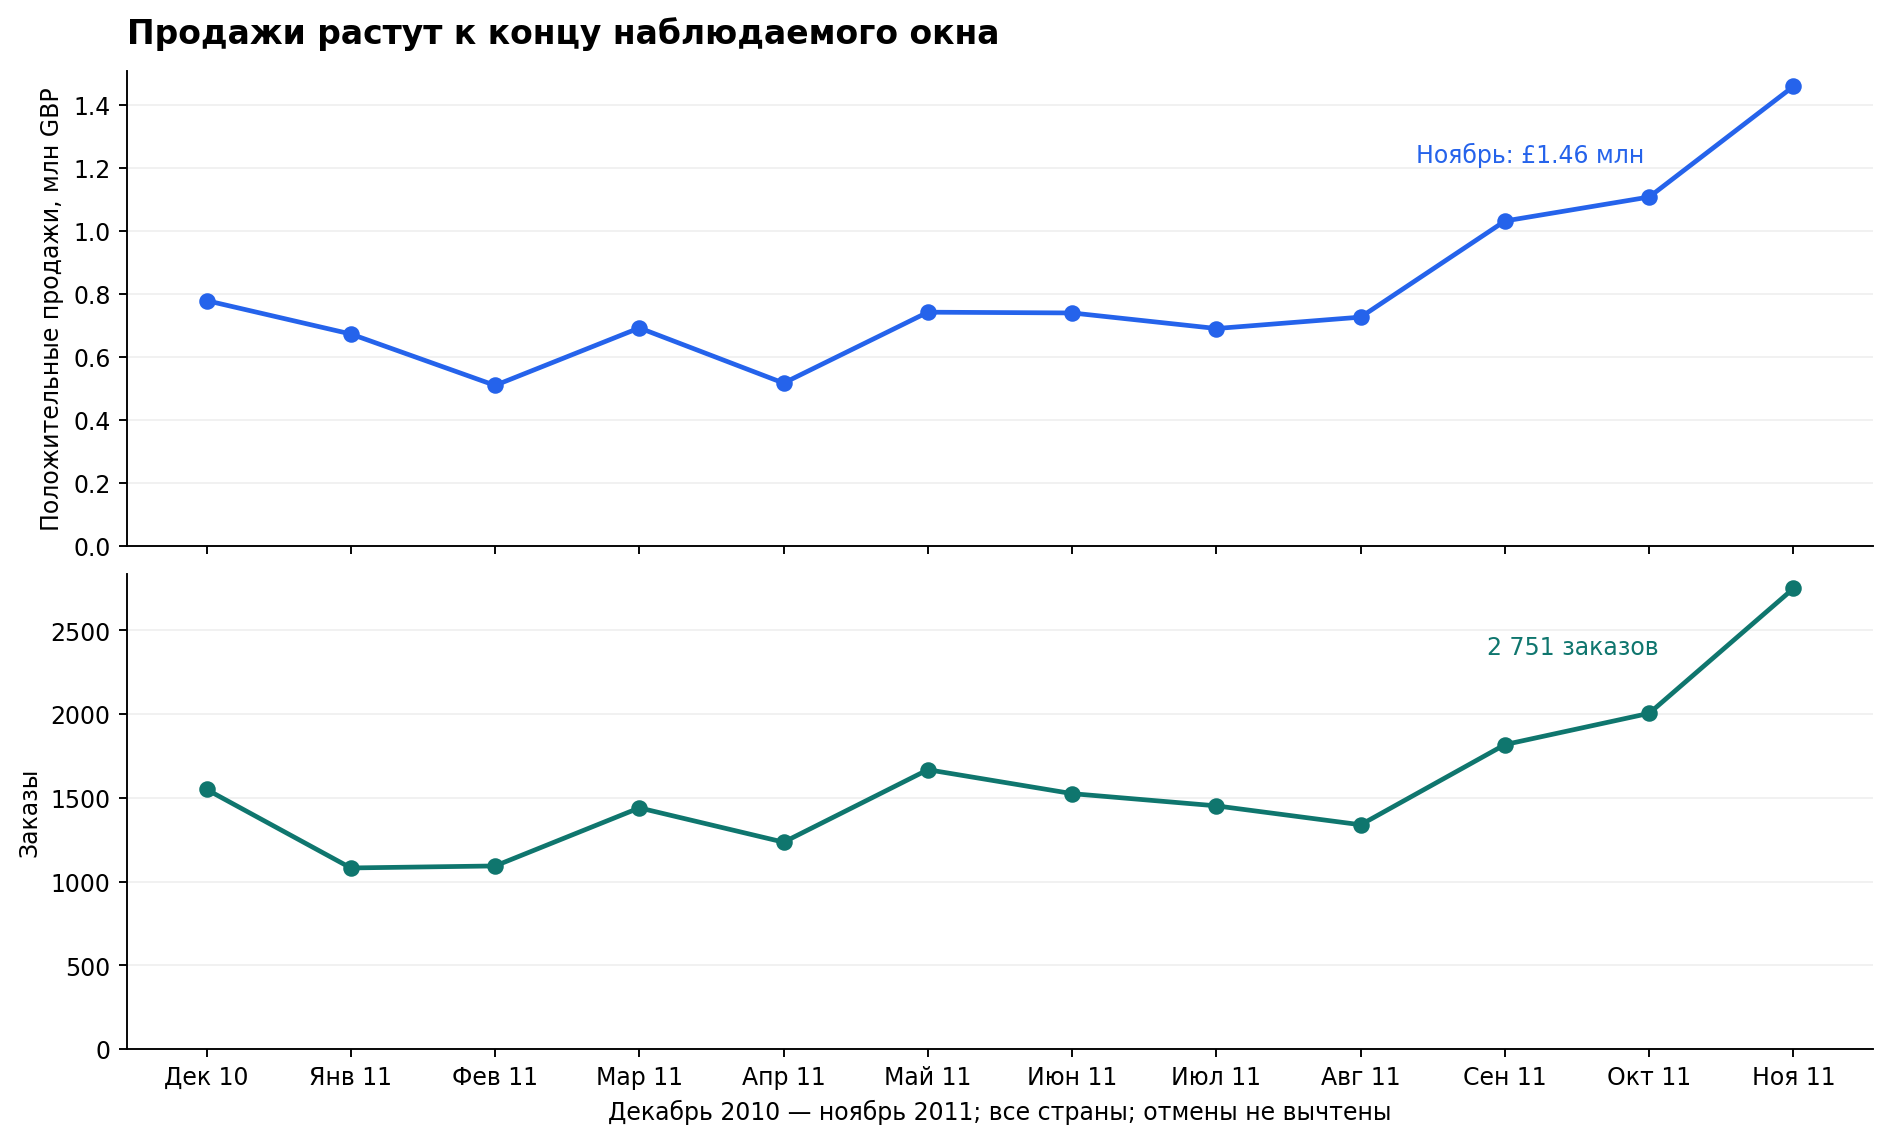

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True, constrained_layout=True)
axes[0].plot(x, monthly['gross_sales_gbp'] / 1e6, color=BLUE, marker='o', linewidth=2)
axes[0].set_title('Продажи растут к концу наблюдаемого окна', fontsize=14, pad=12)
style_axis(axes[0], 'Положительные продажи, млн GBP')
axes[1].plot(x, monthly['orders'], color=TEAL, marker='o', linewidth=2)
style_axis(axes[1], 'Заказы')
axes[0].annotate(f"Ноябрь: £{monthly.iloc[-1]['gross_sales_gbp']/1e6:.2f} млн",
    (x[-1], monthly.iloc[-1]['gross_sales_gbp']/1e6), xytext=(-160, -32), textcoords='offset points', color=BLUE)
axes[1].annotate(f"{int(monthly.iloc[-1]['orders']):,} заказов".replace(',', ' '),
    (x[-1], monthly.iloc[-1]['orders']), xytext=(-130, -28), textcoords='offset points', color=TEAL)
axes[1].set_xlabel('Декабрь 2010 — ноябрь 2011; все страны; отмены не вычтены')
save_figure(fig, '01_monthly_sales_orders')


## 5. Средний и медианный чек

Различие среднего и медианного чека показывает неоднородность размеров заказов.
Крупные счета не удалены автоматически. Для январского пика ниже отдельно
проверим влияние известного крупного счёта с отменой.


Сохранён график: 02_average_median_order.png


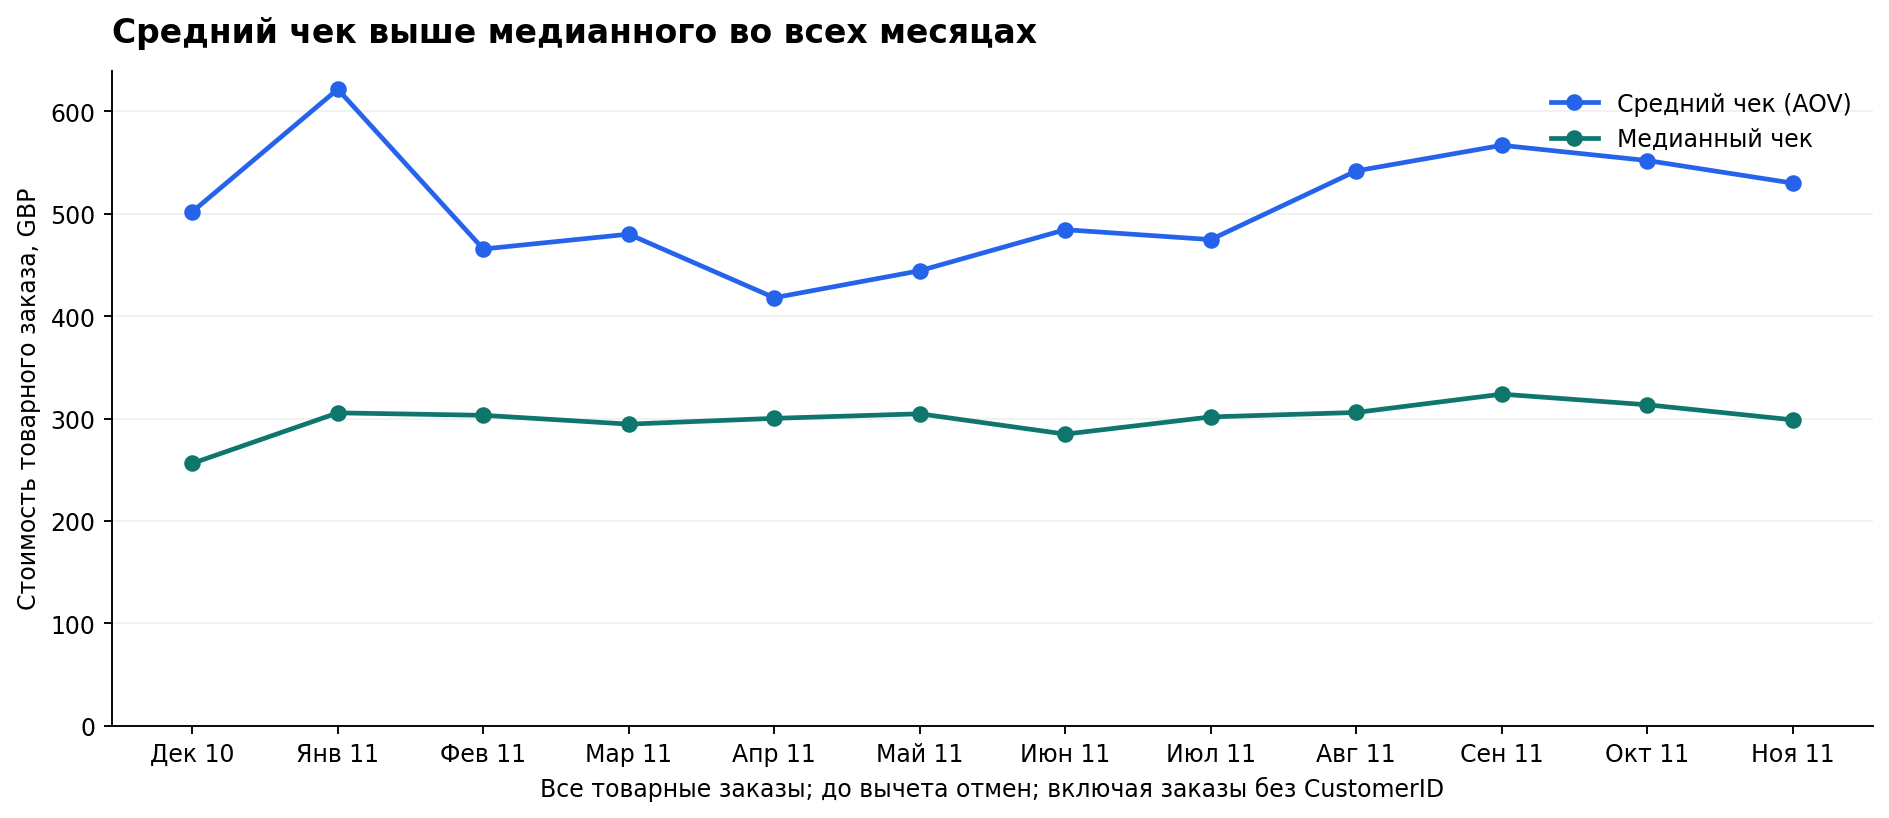

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.7), constrained_layout=True)
ax.plot(x, monthly['aov_gbp'], color=BLUE, marker='o', linewidth=2, label='Средний чек (AOV)')
ax.plot(x, monthly['median_order_gbp'], color=TEAL, marker='o', linewidth=2, label='Медианный чек')
ax.set_title('Средний чек выше медианного во всех месяцах', fontsize=14, pad=12)
style_axis(ax, 'Стоимость товарного заказа, GBP')
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('Все товарные заказы; до вычета отмен; включая заказы без CustomerID')
save_figure(fig, '02_average_median_order')


## 6. Активные клиенты по истории наблюдения

В обеих группах только известные CustomerID. Покупки одного клиента в разных
месяцах отражаются в активности каждого месяца. Ранее наблюдаемых клиентов
может становиться больше просто из-за накопления истории: этот график сам по
себе не доказывает улучшение удержания. Для этого нужны когорты одного возраста.


Сохранён график: 03_observed_customer_groups.png


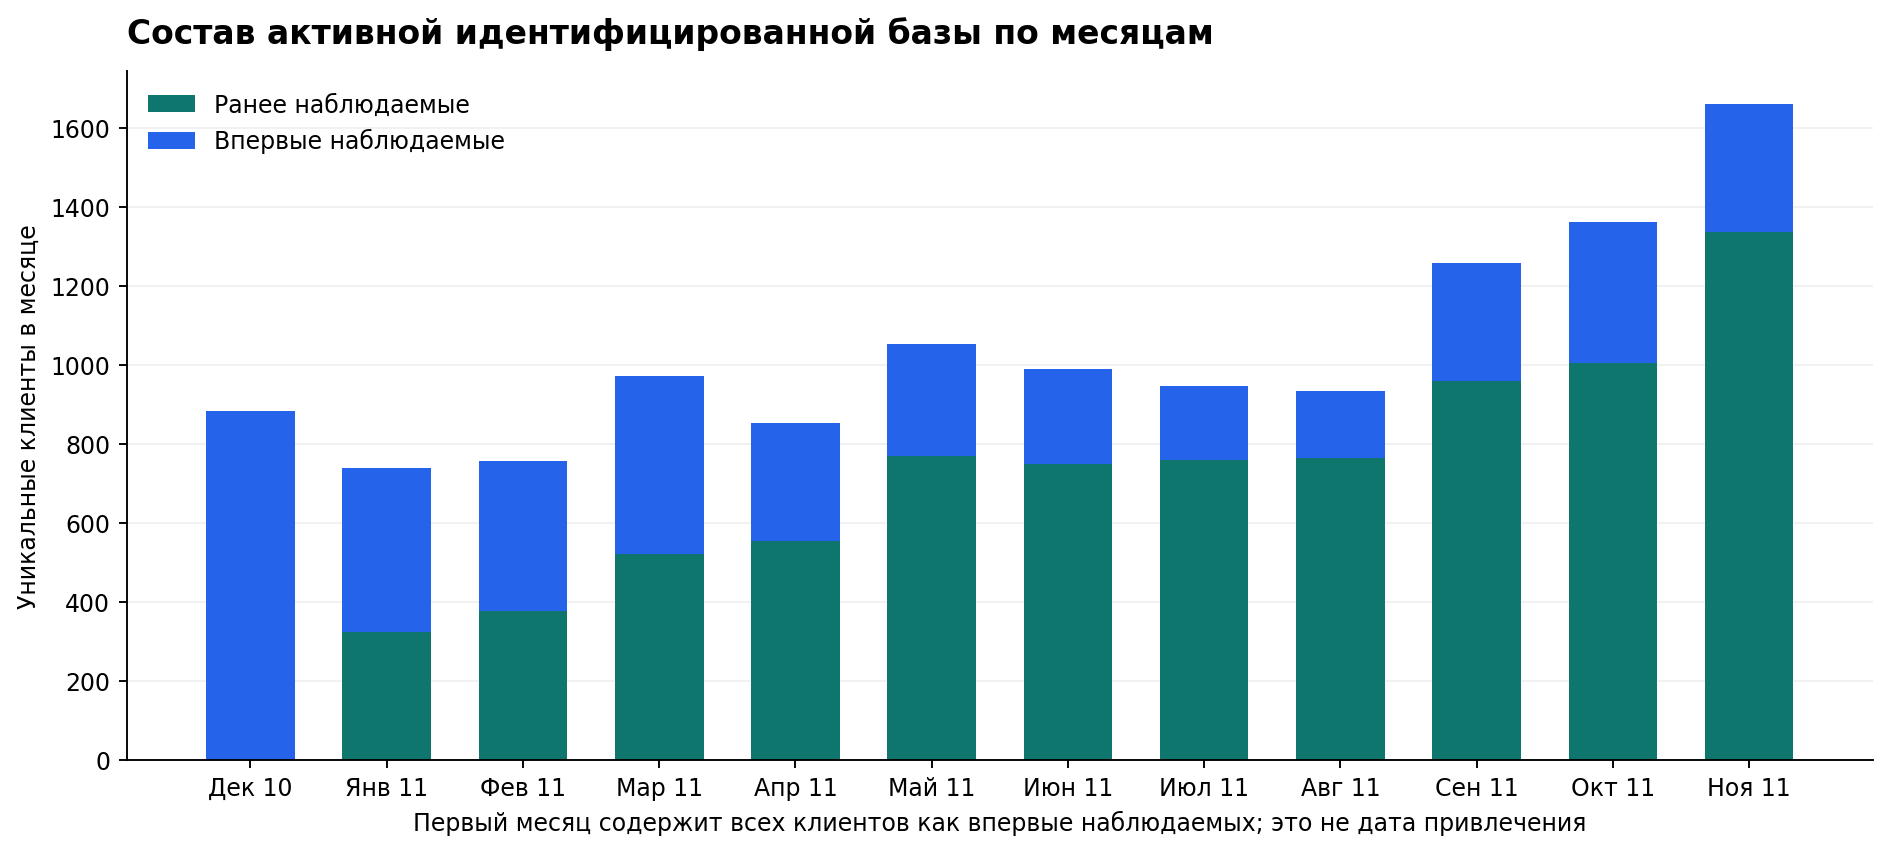

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.9), constrained_layout=True)
ax.bar(x, customer_monthly['previously_observed_customers'], color=TEAL, width=0.65,
       label='Ранее наблюдаемые')
ax.bar(x, customer_monthly['first_observed_customers'],
       bottom=customer_monthly['previously_observed_customers'], color=BLUE, width=0.65,
       label='Впервые наблюдаемые')
ax.set_title('Состав активной идентифицированной базы по месяцам', fontsize=14, pad=12)
style_axis(ax, 'Уникальные клиенты в месяце')
ax.legend(frameon=False, loc='upper left')
ax.set_xlabel('Первый месяц содержит всех клиентов как впервые наблюдаемых; это не дата привлечения')
save_figure(fig, '03_observed_customer_groups')


## 7. Покрытие CustomerID

Полнота идентификации меняется по месяцам. Важно сравнивать общий рост продаж
с ростом той части базы, по которой доступны клиентские выводы. Причины пропусков
из выгрузки неизвестны; не предполагаем случайный характер пропусков.


Сохранён график: 04_monthly_identification_coverage.png


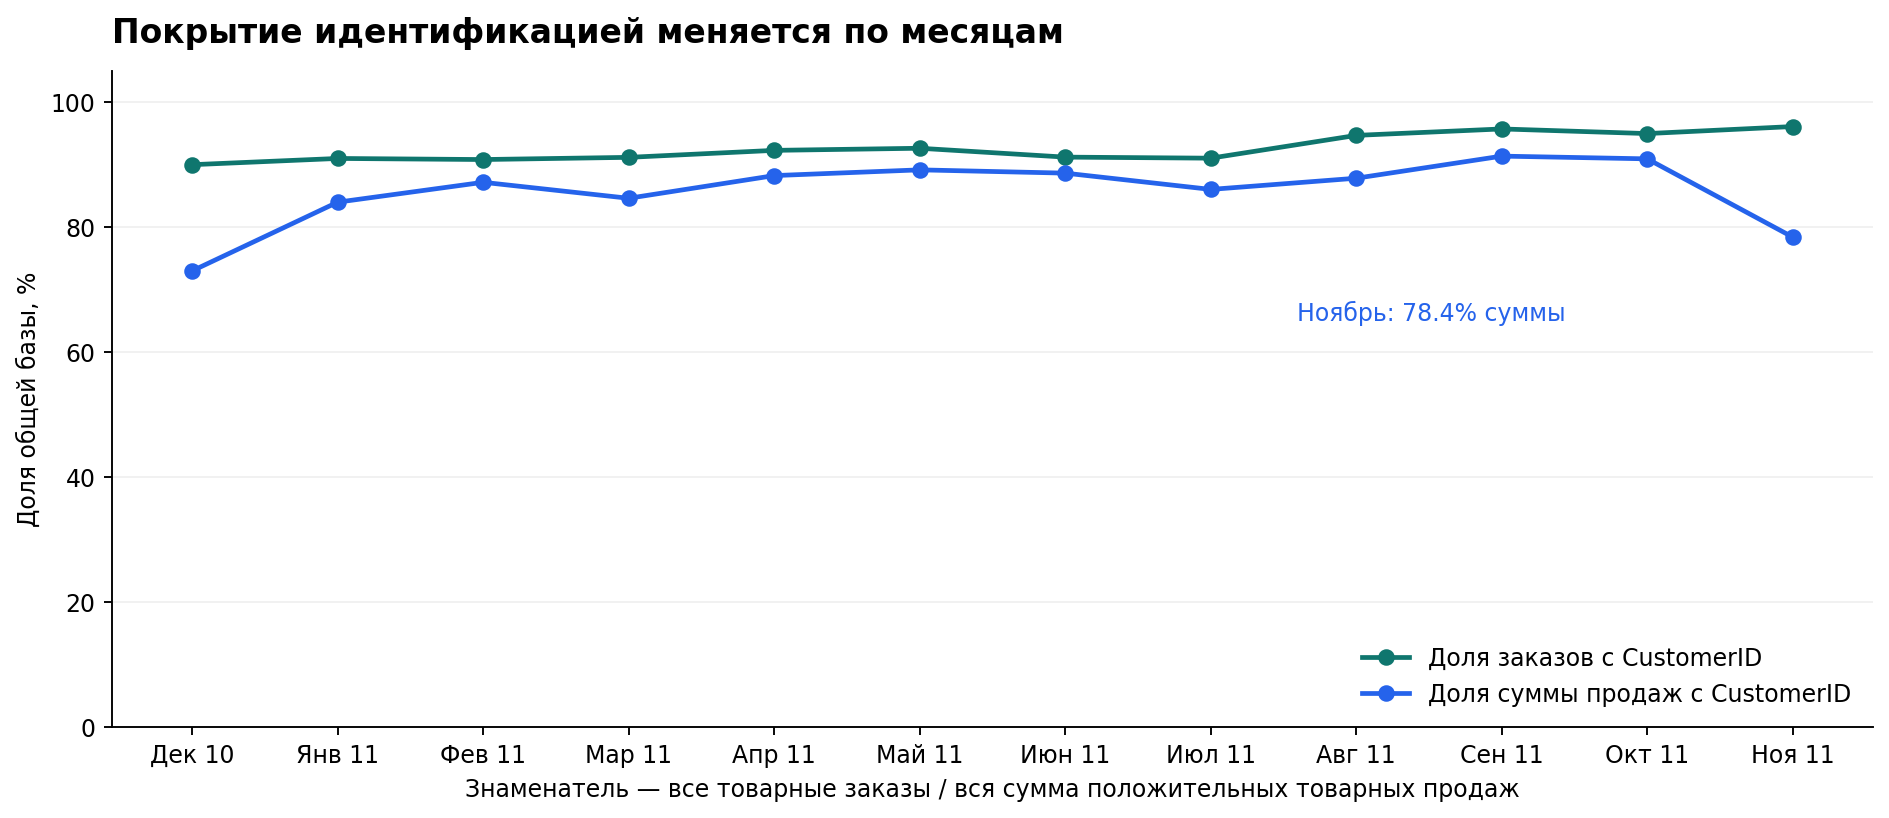

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.7), constrained_layout=True)
ax.plot(x, monthly['identified_orders_pct'], color=TEAL, marker='o', linewidth=2,
        label='Доля заказов с CustomerID')
ax.plot(x, monthly['identified_sales_pct'], color=BLUE, marker='o', linewidth=2,
        label='Доля суммы продаж с CustomerID')
ax.set_title('Покрытие идентификацией меняется по месяцам', fontsize=14, pad=12)
style_axis(ax, 'Доля общей базы, %')
ax.set_ylim(0, 105)
ax.legend(frameon=False, loc='lower right')
ax.annotate(f"Ноябрь: {monthly.iloc[-1]['identified_sales_pct']:.1f}% суммы",
    (x[-1], monthly.iloc[-1]['identified_sales_pct']), xytext=(-210, -35), textcoords='offset points', color=BLUE)
ax.set_xlabel('Знаменатель — все товарные заказы / вся сумма положительных товарных продаж')
save_figure(fig, '04_monthly_identification_coverage')


## 8. Чувствительность к точным повторам и крупному счёту

Альтернативное удаление повторов проверяем по каждому месяцу, а не только в сумме.
Для крупного январского счёта 541431 показываем отдельный сценарий исключения.
Этот сценарий не является полноценным расчётом чистых продаж после всех отмен
и не меняет основную базу. Подтверждающие записи сохранены на этапе 2.


In [9]:
with closing(sqlite3.connect(DB.as_uri() + '?mode=ro', uri=True)) as conn:
    dedup_lines = pd.read_sql_query('''
        SELECT invoice_no, invoice_date, line_amount_gbp
        FROM purchase_lines WHERE is_exact_duplicate = 0
    ''', conn, parse_dates=['invoice_date'])
dedup_orders = dedup_lines.groupby('invoice_no').agg(
    order_date=('invoice_date', 'min'), gross_sales_gbp=('line_amount_gbp', 'sum')).reset_index()
dedup_orders['month'] = dedup_orders['order_date'].dt.strftime('%Y-%m')
dedup_monthly = dedup_orders.groupby('month').agg(
    dedup_sales_gbp=('gross_sales_gbp', 'sum'), dedup_orders=('invoice_no', 'size')).reset_index()
sensitivity = monthly[['month', 'orders', 'gross_sales_gbp', 'sales_mom_pct']].merge(
    dedup_monthly, on='month', validate='one_to_one')
sensitivity['dedup_sales_mom_pct'] = 100 * sensitivity['dedup_sales_gbp'].pct_change()
sensitivity['sales_removed_pct'] = 100 * (1 - sensitivity['dedup_sales_gbp'] / sensitivity['gross_sales_gbp'])
sensitivity['mom_difference_pp'] = sensitivity['dedup_sales_mom_pct'] - sensitivity['sales_mom_pct']
assert np.array_equal(sensitivity['orders'], sensitivity['dedup_orders'])
assert sensitivity['month'].tolist() == expected_months
sensitivity.to_csv(TABLES / 'monthly_duplicate_sensitivity.csv', index=False)

jan = monthly.loc[monthly['month'].eq('2011-01')].iloc[0]
jan_without_largest = orders.loc[orders['month'].eq('2011-01') & orders['invoice_no'].ne('541431')]
jan_aov_scenario = float(jan_without_largest['gross_sales_gbp'].mean())
print(sensitivity[['month', 'sales_removed_pct', 'mom_difference_pp']].round(3).to_string(index=False))
print(f"Январский AOV: £{jan['aov_gbp']:.2f}; без счёта 541431: £{jan_aov_scenario:.2f}")


  month  sales_removed_pct  mom_difference_pp
2010-12              0.295                NaN
2011-01              0.231              0.055
2011-02              0.213              0.013
2011-03              0.206              0.010
2011-04              0.163              0.032
2011-05              0.167             -0.006
2011-06              0.161              0.006
2011-07              0.166             -0.004
2011-08              0.179             -0.013
2011-09              0.209             -0.043
2011-10              0.303             -0.101
2011-11              0.386             -0.110
Январский AOV: £621.58; без счёта 541431: £550.69


## 9. Что объясняет изменение октября → ноября

Это бухгалтерское разложение показателя, а не причинный эффект кампании:

**Sales = Orders × AOV** и **1 + growth(Sales) = (1 + growth(Orders)) × (1 + growth(AOV)).**

Проценты изменений нельзя просто складывать. Для абсолютного изменения используем
симметричное разложение: изменение заказов × средний AOV двух месяцев плюс
изменение AOV × среднее число заказов двух месяцев. Компоненты в точности дают
изменение продаж и не зависят от порядка подстановки. Это описание арифметики.


In [10]:
october = monthly.loc[monthly['month'].eq('2011-10')].iloc[0]
november = monthly.loc[monthly['month'].eq('2011-11')].iloc[0]
nov_clients = customer_monthly.loc[customer_monthly['month'].eq('2011-11')].iloc[0]
sales_delta = float(november['gross_sales_gbp'] - october['gross_sales_gbp'])
orders_component = float((november['orders'] - october['orders']) * (november['aov_gbp'] + october['aov_gbp']) / 2)
aov_component = float((november['aov_gbp'] - october['aov_gbp']) * (november['orders'] + october['orders']) / 2)
assert np.isclose(orders_component + aov_component, sales_delta, rtol=0, atol=0.01)
assert np.isclose(1 + november['sales_mom_pct']/100,
    (1 + november['orders_mom_pct']/100) * (1 + november['aov_mom_pct']/100), rtol=0, atol=1e-12)
decomposition = pd.DataFrame([
    ('orders_component', orders_component), ('aov_component', aov_component), ('total_change', sales_delta)
], columns=['component', 'amount_gbp'])
decomposition.to_csv(TABLES / 'october_november_decomposition.csv', index=False)

summary = {
    'period': '2010-12 through 2011-11', 'peak_sales_month': monthly.loc[monthly['gross_sales_gbp'].idxmax(), 'month'],
    'november_sales_gbp': float(november['gross_sales_gbp']), 'november_orders': int(november['orders']),
    'november_aov_gbp': float(november['aov_gbp']), 'november_median_order_gbp': float(november['median_order_gbp']),
    'november_sales_mom_pct': float(november['sales_mom_pct']), 'november_orders_mom_pct': float(november['orders_mom_pct']),
    'november_aov_mom_pct': float(november['aov_mom_pct']),
    'november_identified_sales_growth_pct': float(100 * (november['identified_sales_gbp'] / october['identified_sales_gbp'] - 1)),
    'october_identified_sales_pct': float(october['identified_sales_pct']),
    'november_identified_sales_pct': float(november['identified_sales_pct']),
    'october_unidentified_sales_gbp': float(october['gross_sales_gbp'] - october['identified_sales_gbp']),
    'november_unidentified_sales_gbp': float(november['gross_sales_gbp'] - november['identified_sales_gbp']),
    'orders_component_gbp': orders_component, 'aov_component_gbp': aov_component,
    'total_sales_delta_gbp': sales_delta,
    'november_active_identified_customers': int(nov_clients['active_identified_customers']),
    'november_previously_observed_customers': int(nov_clients['previously_observed_customers']),
    'november_previously_observed_customers_pct': float(nov_clients['previously_observed_customers_pct']),
    'november_previously_observed_sales_pct': float(nov_clients['previous_months_customers_sales_pct']),
    'january_aov_gbp': float(jan['aov_gbp']), 'january_aov_without_541431_gbp': jan_aov_scenario,
    'max_monthly_duplicate_sales_removed_pct': float(sensitivity['sales_removed_pct'].max()),
    'max_absolute_duplicate_mom_difference_pp': float(sensitivity['mom_difference_pp'].abs().max()),
    'source_sha256': quality['source_sha256'],
    'checks': ['monthly_sql_pandas', 'per_customer_sql_pandas', 'customer_group_membership',
               'stage2_control_totals', 'growth_identity', 'duplicate_sensitivity'],
}
(ROOT / 'reports/stage3_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2) + '\n')

def fmt(value, digits=0):
    return f'{value:,.{digits}f}'.replace(',', ' ')

table = '\n'.join(f"| {r.month} | {fmt(r.orders)} | {fmt(r.gross_sales_gbp, 2)} | {fmt(r.aov_gbp, 2)} | {fmt(r.active_identified_customers)} |"
                  for r in monthly.itertuples())
report = f'''# Retail Customer Analytics — этап 3: SQL-метрики и первые выводы

Окно: **декабрь 2010 — ноябрь 2011**, все страны. Продажи означают положительные товарные продажи до вычета отмен. Состав базы и контрольные суммы совпадают с этапом 2.

## Месячные показатели

| Месяц | Заказы | Продажи, GBP | AOV, GBP | Активные известные клиенты |
| --- | ---: | ---: | ---: | ---: |
{table}

В reports/tables/monthly_metrics.csv также есть изменение к предыдущему месяцу, количество единиц на заказ, медианный чек и покрытие CustomerID. В первом месяце изменения к предыдущему месяцу отсутствуют.

## 1. Ноябрьский рост связан с числом заказов

В ноябре — {fmt(november['orders'])} заказов и {fmt(november['gross_sales_gbp'], 2)} GBP продаж, максимум обоих показателей в наблюдаемом окне. К октябрю продажи выросли на {fmt(november['sales_mom_pct'], 2)}%, заказы — на {fmt(november['orders_mom_pct'], 2)}%, средний чек снизился на {fmt(-november['aov_mom_pct'], 2)}%.

Арифметическое разложение изменения продаж: компонент числа заказов +{fmt(orders_component, 2)} GBP, компонент среднего чека {fmt(aov_component, 2)} GBP, вместе +{fmt(sales_delta, 2)} GBP. Это описание изменения метрики, а не оценка причинного эффекта маркетинга.

Действие: при разборе ноябрьской нагрузки смотреть прежде всего на объём заказов. Из выгрузки не видно, какая акция или канал объясняют рост; устойчивую сезонность на одном полном годовом окне не устанавливаем.

## 2. Известная клиентская база росла иначе, чем общие продажи

Доля суммы продаж с CustomerID снизилась с {fmt(october['identified_sales_pct'], 2)}% в октябре до {fmt(november['identified_sales_pct'], 2)}% в ноябре. В идентифицированной части продажи выросли на {fmt(summary['november_identified_sales_growth_pct'], 2)}%, тогда как общая сумма — на {fmt(november['sales_mom_pct'], 2)}%.

Продажи без CustomerID: {fmt(summary['october_unidentified_sales_gbp'], 2)} GBP в октябре и {fmt(summary['november_unidentified_sales_gbp'], 2)} GBP в ноябре. Из данных нельзя установить причину пропусков или считать их случайными.

Действие: контролировать покрытие ID в отчётности и уточнить у владельца данных происхождение неидентифицированных заказов. Выводы о CRM-аудитории относятся к известным клиентам; общую динамику магазина на них автоматически не переносим.

## 3. Ранее наблюдаемые клиенты дают большую часть ноябрьских известных продаж

В ноябре активно {fmt(nov_clients['active_identified_customers'])} известных клиентов, из них {fmt(nov_clients['previously_observed_customers'])} ({fmt(nov_clients['previously_observed_customers_pct'], 2)}%) впервые наблюдались в предыдущих месяцах. На них приходится {fmt(nov_clients['previous_months_customers_sales_pct'], 2)}% суммы продаж идентифицированной базы ноября.

Группа определяется по месяцу первой наблюдаемой покупки. Несколько покупок нового клиента в его первом месяце все относятся к группе впервые наблюдаемых. Увеличение доли ранее наблюдаемых не доказывает улучшение retention: история накапливается, а возраст когорт различается.

Действие: на следующем этапе сравнить удержание когорт на одинаковом возрасте и разделить активных повторных клиентов и давно не покупавших. Массовую скидку этим результатом не обосновываем.

## 4. Средний чек чувствителен к крупным счетам

Средний чек выше медианного во всех 12 месяцах. В ноябре AOV — {fmt(november['aov_gbp'], 2)} GBP, медиана — {fmt(november['median_order_gbp'], 2)} GBP. Это согласуется с неоднородностью размеров заказов; принадлежность конкретного клиента к оптовикам не установлена.

Январский AOV составляет {fmt(jan['aov_gbp'], 2)} GBP. Без одного известного крупного счёта 541431 с записью отмены он составил бы {fmt(jan_aov_scenario, 2)} GBP. Это только диагностический сценарий, не полная поправка на все отмены.

Действие: показывать медиану рядом со средним и проверять крупные счета перед выбором «ценных» клиентов. Gross Monetary не равен чистой ценности клиента.

## Устойчивость и проверки

Удаление точных повторов не меняет число заказов ни в одном месяце. Максимальное снижение месячной суммы — {fmt(summary['max_monthly_duplicate_sales_removed_pct'], 3)}%, максимальное абсолютное изменение месячного темпа продаж — {fmt(summary['max_absolute_duplicate_mom_difference_pp'], 3)} процентного пункта. Основная версия продолжает сохранять повторы.

SQL/pandas сверены для каждого месяца и каждого клиента. Проверены состав групп, отсутствие размножения данных в соединении, контрольные суммы этапа 2 и тождество разложения роста. Все кодовые ячейки аналитического ноутбука выполнены последовательно; интеграция с интерфейсом Jupyter отдельно не тестировалась.

## Материалы и следующий этап

- sql/02_monthly_metrics.sql, 03_customer_metrics.sql, 04_customer_monthly.sql.
- notebooks/02_customer_analytics.ipynb — запросы, проверки, графики, чувствительность и этот отчёт.
- reports/figures/ — четыре графика в PNG и SVG.
- reports/tables/ — месячные/клиентские показатели и диагностика.
- reports/stage3_summary.json — машинные контрольные показатели.

Далее: cohort retention, повторная покупка за 30 дней с полным сроком наблюдения, RFM и концентрация продаж. Выводы этого этапа предварительные; целевой сегмент и предложение для будущего A/B-теста ещё не выбраны.

Источник: Chen, D. (2015). Online Retail. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33. CC BY 4.0. Контрольная сумма источника сохранена в source_manifest.json.
'''
(ROOT / 'reports/stage3_findings.md').write_text(report, encoding='utf-8')
print(decomposition.round(2).to_string(index=False))
print('Сохранены SQL-метрики, четыре графика, контрольные показатели и отчёт этапа 3.')


       component  amount_gbp
orders_component   403530.65
   aov_component   -52454.94
    total_change   351075.71
Сохранены SQL-метрики, четыре графика, контрольные показатели и отчёт этапа 3.


## 10. Когортное удержание

Когорта — месяц первой наблюдаемой покупки. Retention M1 — доля клиентов
когорты, купивших в следующем календарном месяце. Покупки во всех предыдущих
месяцах не требуются: клиент может отсутствовать в M1 и снова появиться в M2.

Покупка в конкретном календарном месяце и покупка за 30 суток после первого
заказа — разные метрики с разными окнами. Декабрь 2010 отдельно отмечаем: в нём
могут быть существовавшие до выгрузки клиенты. Недоступные будущие ячейки — NaN,
наблюдаемый месяц без покупок — 0. M0 = 100% по определению.


In [11]:
CUTOFF = pd.Timestamp(quality['analysis_end_exclusive'])
cohort_activity = query_file('05_cohort_activity.sql')
cohort_sizes = customers.groupby('first_observed_month').size().reindex(expected_months)
cohort_sizes.index.name = 'cohort_month'
cohort_counts = pd.DataFrame(np.nan, index=cohort_sizes.index, columns=range(12))
cohort_counts.columns.name = 'cohort_age'
for i, month in enumerate(expected_months):
    cohort_counts.loc[month, range(12 - i)] = 0
for row in cohort_activity.itertuples():
    cohort_counts.loc[row.cohort_month, row.cohort_age] = row.active_customers
retention = cohort_counts.div(cohort_sizes, axis=0)

# Независимая проверка через клиент–месяц в pandas.
activity = known[['customer_id', 'month', 'first_observed_month']].drop_duplicates().copy()
activity['age'] = (pd.PeriodIndex(activity['month'], freq='M').asi8
                   - pd.PeriodIndex(activity['first_observed_month'], freq='M').asi8)
expected_activity = activity.groupby(['first_observed_month', 'age']).size()
for row in cohort_activity.itertuples():
    assert row.active_customers == expected_activity.loc[(row.cohort_month, row.cohort_age)]
assert len(cohort_activity) == len(expected_activity)
assert np.array_equal(cohort_counts[0], cohort_sizes)
assert retention[0].eq(1).all()
for i, month in enumerate(expected_months):
    assert cohort_counts.loc[month, range(12 - i, 12)].isna().all()
    observed = cohort_counts.loc[month, range(12 - i)]
    assert observed.notna().all() and observed.between(0, cohort_sizes.loc[month]).all()

cohort_overview = pd.DataFrame({'customers': cohort_sizes, 'retention_m1_pct': 100 * retention[1]})
cohort_activity.to_csv(TABLES / 'cohort_activity.csv', index=False)
cohort_counts.to_csv(TABLES / 'cohort_customer_counts.csv')
retention.to_csv(TABLES / 'cohort_retention.csv')
cohort_overview.to_csv(TABLES / 'cohort_overview.csv')
eligible_m1 = cohort_overview.loc['2011-01':'2011-10']
weighted_m1_pct = float(100 * cohort_counts.loc['2011-01':'2011-10', 1].sum() / eligible_m1['customers'].sum())
print(cohort_overview.round(2).to_string())
print(f'Взвешенный retention M1 для когорт января–октября: {weighted_m1_pct:.2f}%')


              customers  retention_m1_pct
cohort_month                             
2010-12             884             36.54
2011-01             416             21.88
2011-02             380             18.68
2011-03             452             14.82
2011-04             300             21.00
2011-05             284             19.01
2011-06             242             17.36
2011-07             187             17.65
2011-08             169             20.12
2011-09             299             23.41
2011-10             357             23.53
2011-11             323               NaN
Взвешенный retention M1 для когорт января–октября: 19.73%


Сохранён график: 05_cohort_retention.png


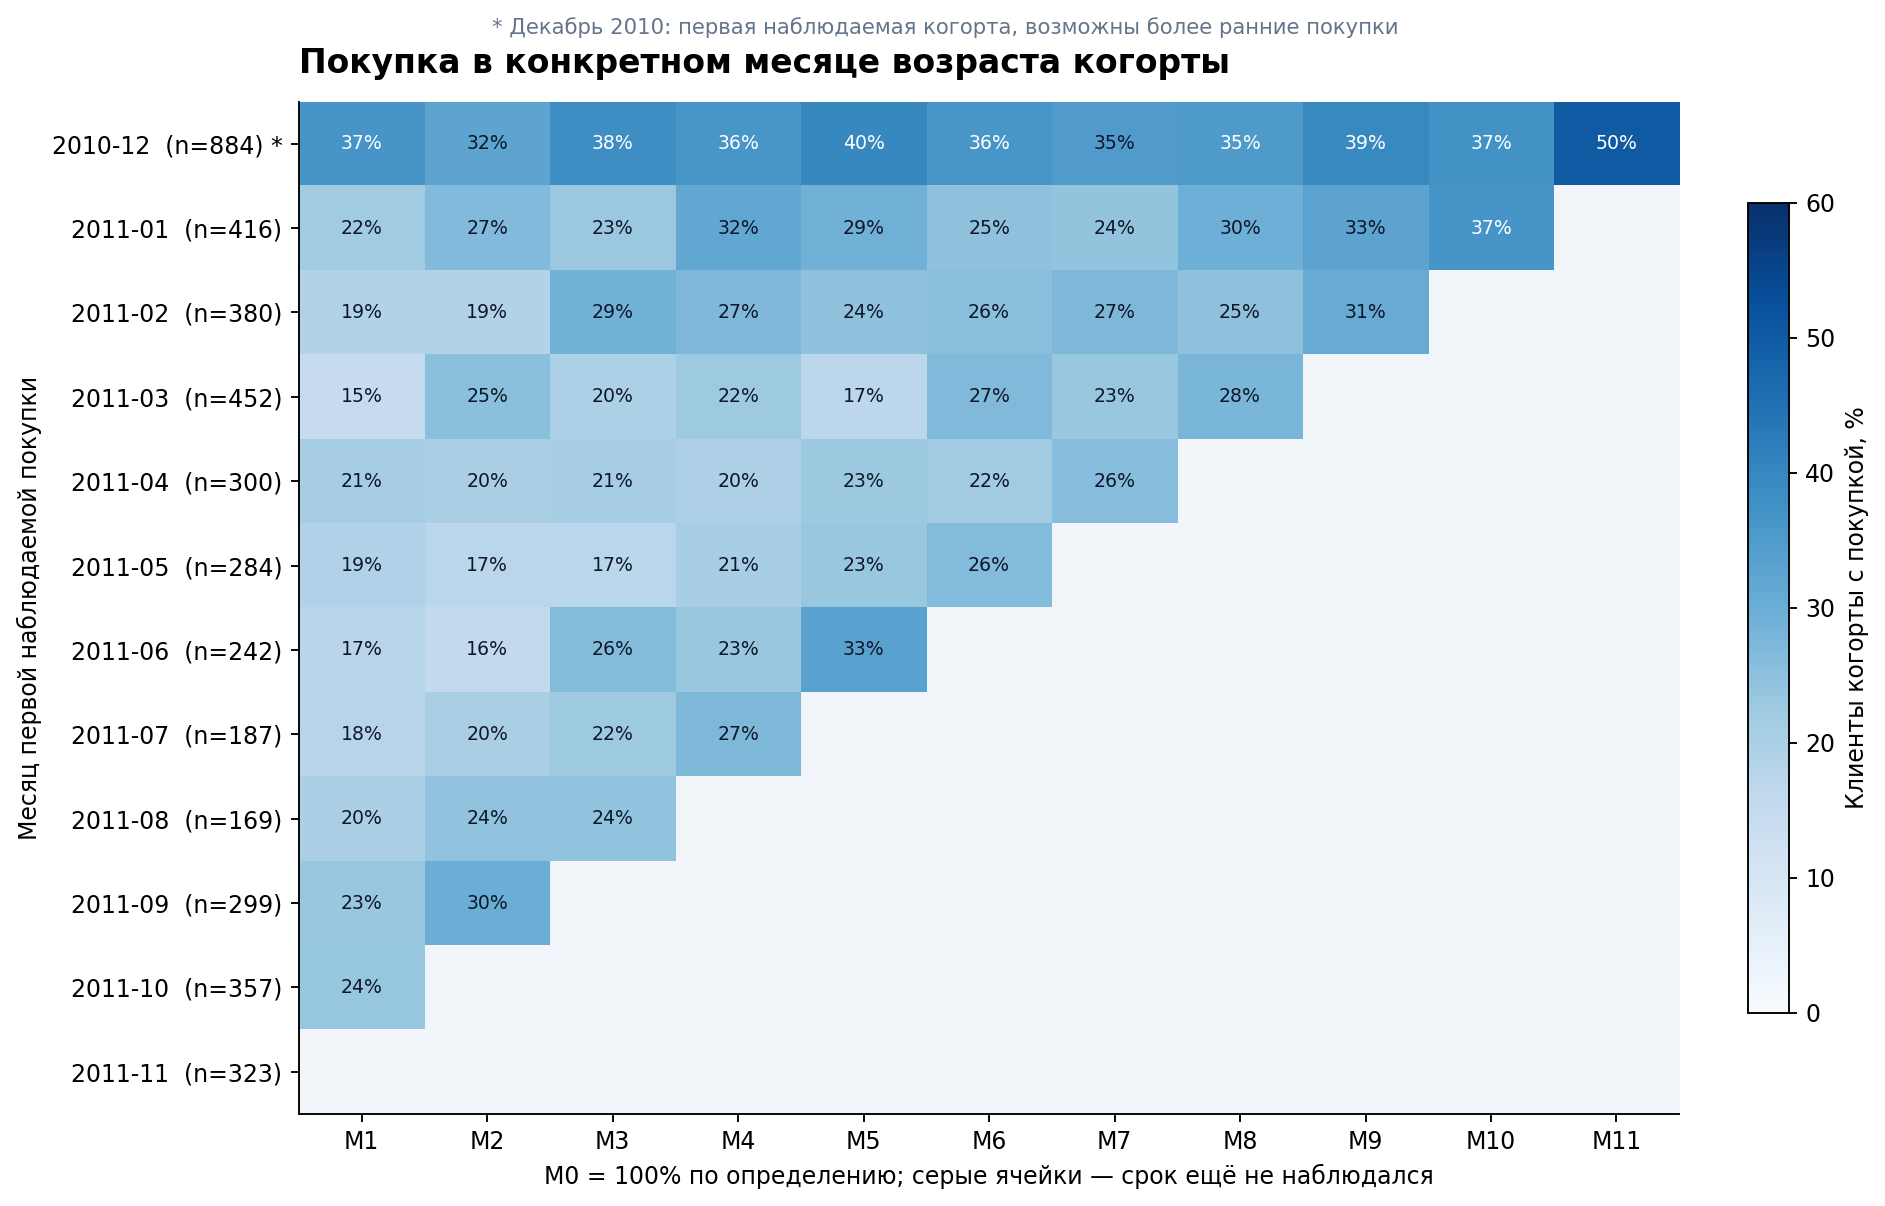

In [12]:
fig, ax = plt.subplots(figsize=(11, 6.8), constrained_layout=True)
data = retention.iloc[:, 1:] * 100
cmap = plt.get_cmap('Blues').copy()
cmap.set_bad('#F1F5F9')
im = ax.imshow(np.ma.masked_invalid(data.to_numpy()), cmap=cmap, vmin=0, vmax=60, aspect='auto')
ax.set_xticks(range(11), [f'M{i}' for i in range(1, 12)])
cohort_labels = [f'{month}  (n={cohort_sizes.loc[month]})' for month in expected_months]
cohort_labels[0] += ' *'
ax.set_yticks(range(12), cohort_labels)
ax.set_title('Покупка в конкретном месяце возраста когорты', fontsize=14, pad=12)
ax.set_xlabel('M0 = 100% по определению; серые ячейки — срок ещё не наблюдался')
ax.set_ylabel('Месяц первой наблюдаемой покупки')
for i in range(12):
    for j in range(11):
        value = data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f'{value:.0f}%', ha='center', va='center', fontsize=8,
                    color='white' if value >= 35 else '#0F172A')
fig.colorbar(im, ax=ax, label='Клиенты когорты с покупкой, %', shrink=0.8)
fig.suptitle('* Декабрь 2010: первая наблюдаемая когорта, возможны более ранние покупки',
             fontsize=9, color=GRAY, y=1.02)
save_figure(fig, '05_cohort_retention')


## 11. Повторная покупка за 30 дней

Клиент должен иметь полные 30 суток наблюдения: first_order + 30 дней строго
раньше исключённой границы 01.12.2011. Повтор — другой счёт со временем строго
позже первого и не позже first_order + 30 дней. Одновременные счета не считаем
возвращением: они могут быть разделением одной покупки.

Для клиентов без полного окна результат — NULL, не 0. Ноябрьскую когорту в
итоговый знаменатель не включаем. Декабрьскую когорту показываем отдельно,
общий ориентир считаем для впервые наблюдаемых клиентов января–октября.


In [13]:
with closing(sqlite3.connect(DB.as_uri() + '?mode=ro', uri=True)) as conn:
    repeat30 = pd.read_sql_query((ROOT / 'sql/06_repeat_purchase_30d.sql').read_text(), conn,
        params={'cutoff': CUTOFF.strftime('%Y-%m-%d %H:%M:%S')},
        parse_dates=['first_order_date', 'next_order_date'])

first_times = known.groupby('customer_id')['order_date'].min()
after_first = known.loc[known['order_date'].gt(known['customer_id'].map(first_times))]
next_times = after_first.groupby('customer_id')['order_date'].min()
pr = pd.DataFrame({'first_order_date': first_times, 'next_order_date': next_times})
pr['eligible_30d'] = (pr['first_order_date'] + pd.Timedelta(days=30)).lt(CUTOFF)
pr['repeat_within_30d'] = pr['next_order_date'].le(pr['first_order_date'] + pd.Timedelta(days=30)).astype(float)
pr.loc[~pr['eligible_30d'], 'repeat_within_30d'] = np.nan
sr = repeat30.set_index('customer_id').sort_index()
pr = pr.sort_index()
assert sr.index.tolist() == pr.index.tolist()
assert np.array_equal(sr['eligible_30d'].astype(bool), pr['eligible_30d'])
assert np.allclose(sr['repeat_within_30d'], pr['repeat_within_30d'], rtol=0, atol=0, equal_nan=True)
for col in ['first_order_date', 'next_order_date']:
    pd.testing.assert_series_equal(sr[col], pr[col], check_names=False)
assert repeat30.loc[repeat30['eligible_30d'].eq(0), 'repeat_within_30d'].isna().all()

repeat_by_cohort = repeat30.groupby('cohort_month').agg(
    customers=('customer_id', 'size'), eligible_customers=('eligible_30d', 'sum'),
    repeated_customers=('repeat_within_30d', lambda s: s.sum(min_count=1)),
    repeat_30d_pct=('repeat_within_30d', lambda s: 100 * s.mean()))
eligible_repeat = repeat30.loc[repeat30['eligible_30d'].eq(1) & repeat30['cohort_month'].ne('2010-12')]
repeat_pct = float(100 * eligible_repeat['repeat_within_30d'].mean())
repeat_count = int(eligible_repeat['repeat_within_30d'].sum())
same_first_extra_invoices = int(known['order_date'].eq(known['customer_id'].map(first_times)).sum() - len(first_times))
repeat30.to_csv(TABLES / 'customer_repeat_30d.csv', index=False)
repeat_by_cohort.to_csv(TABLES / 'cohort_repeat_30d.csv')
print(repeat_by_cohort.round(2).to_string())
print(f'Январь–октябрь: {repeat_count} из {len(eligible_repeat)} ({repeat_pct:.2f}%)')
print('Дополнительных счетов с временем первого заказа:', same_first_extra_invoices)


              customers  eligible_customers  repeated_customers  repeat_30d_pct
cohort_month                                                                   
2010-12             884                 884               308.0           34.84
2011-01             416                 416                83.0           19.95
2011-02             380                 380                58.0           15.26
2011-03             452                 452                73.0           16.15
2011-04             300                 300                46.0           15.33
2011-05             284                 284                50.0           17.61
2011-06             242                 242                41.0           16.94
2011-07             187                 187                40.0           21.39
2011-08             169                 169                24.0           14.20
2011-09             299                 299                51.0           17.06
2011-10             357                 

Сохранён график: 06_repeat_purchase_30d.png


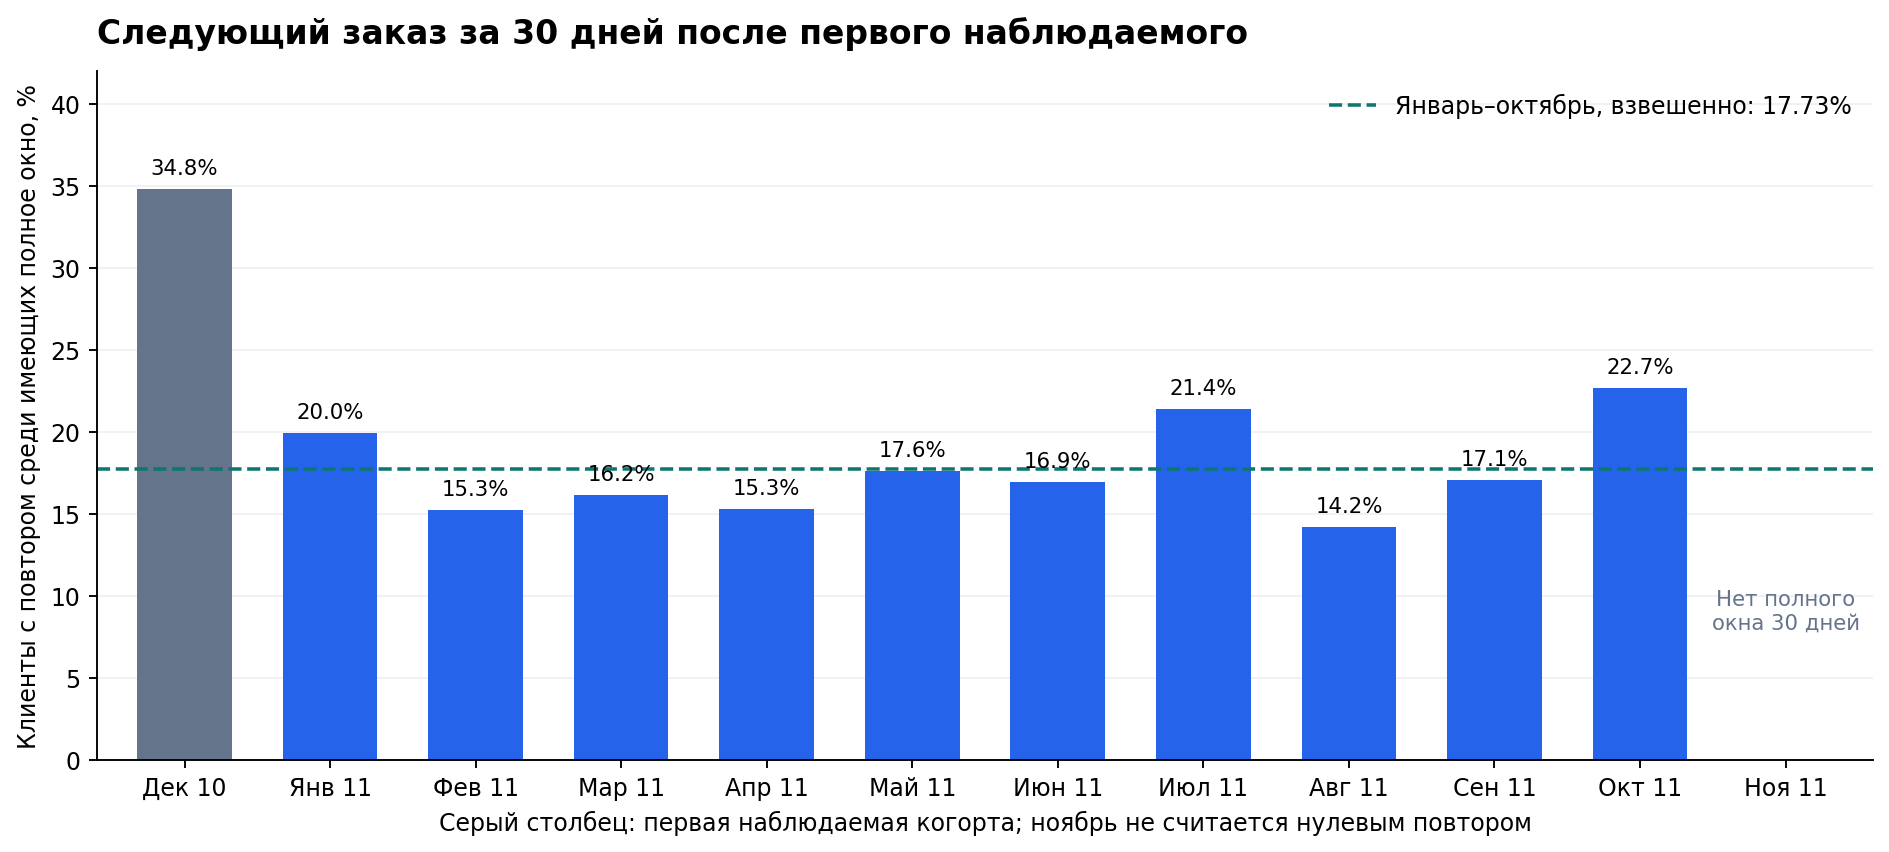

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.9), constrained_layout=True)
rates = repeat_by_cohort['repeat_30d_pct'].to_numpy()
colors = [GRAY] + [BLUE] * 10 + ['#E2E8F0']
ax.bar(x[:-1], rates[:-1], color=colors[:-1], width=0.65)
for i, value in enumerate(rates[:-1]):
    ax.text(i, value + 0.9, f'{value:.1f}%', ha='center', fontsize=9)
ax.axhline(repeat_pct, color=TEAL, linestyle='--', linewidth=1.5,
           label=f'Январь–октябрь, взвешенно: {repeat_pct:.2f}%')
ax.text(11, 8, 'Нет полного\nокна 30 дней', ha='center', color=GRAY, fontsize=9)
ax.set_title('Следующий заказ за 30 дней после первого наблюдаемого', fontsize=14, pad=12)
style_axis(ax, 'Клиенты с повтором среди имеющих полное окно, %')
ax.set_ylim(0, 42)
ax.set_xlim(-0.6, 11.6)
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('Серый столбец: первая наблюдаемая когорта; ноябрь не считается нулевым повтором')
save_figure(fig, '06_repeat_purchase_30d')


## 12. RFM на 01.12.2011

- R: календарные дни от даты последнего заказа до среза. Время суток не влияет.
- F: число различных счетов клиента в окне.
- M: положительные товарные продажи за окно до вычета отмен.

Применяем согласованные в постановке правила сверху вниз. Ценные: R ≤ 30,
F ≥ 3, M ≥ 75-го перцентиля M. Затем активные повторные (R ≤ 60, F ≥ 3),
недавние однократные (R ≤ 30, F = 1), давно не покупавшие повторные (R > 90,
F ≥ 2), остальные. Это прозрачные эвристики, не доказанный цикл покупки.
Дата среза фиксирована: сегодняшняя дата не используется.


In [15]:
SEGMENTS = ['Активные ценные', 'Активные повторные', 'Недавние однократные',
            'Давно не покупавшие повторные', 'Остальные']

def make_rfm(order_frame):
    result = order_frame.groupby('customer_id').agg(
        first_order_date=('order_date', 'min'), last_order_date=('order_date', 'max'),
        frequency=('invoice_no', 'nunique'), monetary_gbp=('gross_sales_gbp', 'sum')).reset_index()
    result['recency_days'] = (CUTOFF - result['last_order_date'].dt.normalize()).dt.days
    m75 = float(result['monetary_gbp'].quantile(0.75))
    R, F, M = result['recency_days'], result['frequency'], result['monetary_gbp']
    rules = [(R <= 30) & (F >= 3) & (M >= m75), (R <= 60) & (F >= 3),
             (R <= 30) & (F == 1), (R > 90) & (F >= 2)]
    result['segment'] = np.select(rules, SEGMENTS[:-1], default=SEGMENTS[-1])
    return result, m75

rfm, monetary_p75 = make_rfm(known)
assert rfm['customer_id'].is_unique and len(rfm) == quality['identified_customers']
assert rfm['recency_days'].between(1, 365).all()
assert rfm['frequency'].ge(1).all() and rfm['monetary_gbp'].gt(0).all()
assert rfm['frequency'].sum() == len(known)
assert np.isclose(rfm['monetary_gbp'].sum(), quality['identified_gross_sales_gbp'], rtol=0, atol=0.01)
check_rfm = rfm.set_index('customer_id').sort_index()
assert np.array_equal(check_rfm['frequency'], sc['orders'])
assert np.allclose(check_rfm['monetary_gbp'], sc['gross_sales_gbp'], rtol=0, atol=0.01)

segment_summary = rfm.groupby('segment').agg(
    customers=('customer_id', 'size'), monetary_gbp=('monetary_gbp', 'sum'),
    median_recency_days=('recency_days', 'median'), median_frequency=('frequency', 'median'),
    median_monetary_gbp=('monetary_gbp', 'median')).reindex(SEGMENTS)
segment_summary['customers_pct'] = 100 * segment_summary['customers'] / len(rfm)
segment_summary['monetary_pct'] = 100 * segment_summary['monetary_gbp'] / rfm['monetary_gbp'].sum()
assert segment_summary['customers'].sum() == len(rfm)
assert np.isclose(segment_summary['monetary_pct'].sum(), 100)
rfm.to_csv(TABLES / 'rfm_customers.csv', index=False)
segment_summary.to_csv(TABLES / 'rfm_segments.csv')
print(f'75-й перцентиль M: £{monetary_p75:.2f}')
print(segment_summary.round(2).to_string())


75-й перцентиль M: £1573.20
                               customers  monetary_gbp  median_recency_days  median_frequency  median_monetary_gbp  customers_pct  monetary_pct
segment                                                                                                                                        
Активные ценные                      678    5123988.91                 10.0               9.0              3369.62          15.79         62.13
Активные повторные                   808    1191834.17                 24.0               4.0              1118.31          18.82         14.45
Недавние однократные                 269      91810.10                 16.0               1.0               261.11           6.27          1.11
Давно не покупавшие повторные        589     633590.29                161.0               2.0               645.65          13.72          7.68
Остальные                           1949    1206612.75                 80.0               1.0               

Сохранён график: 07_rfm_segments.png


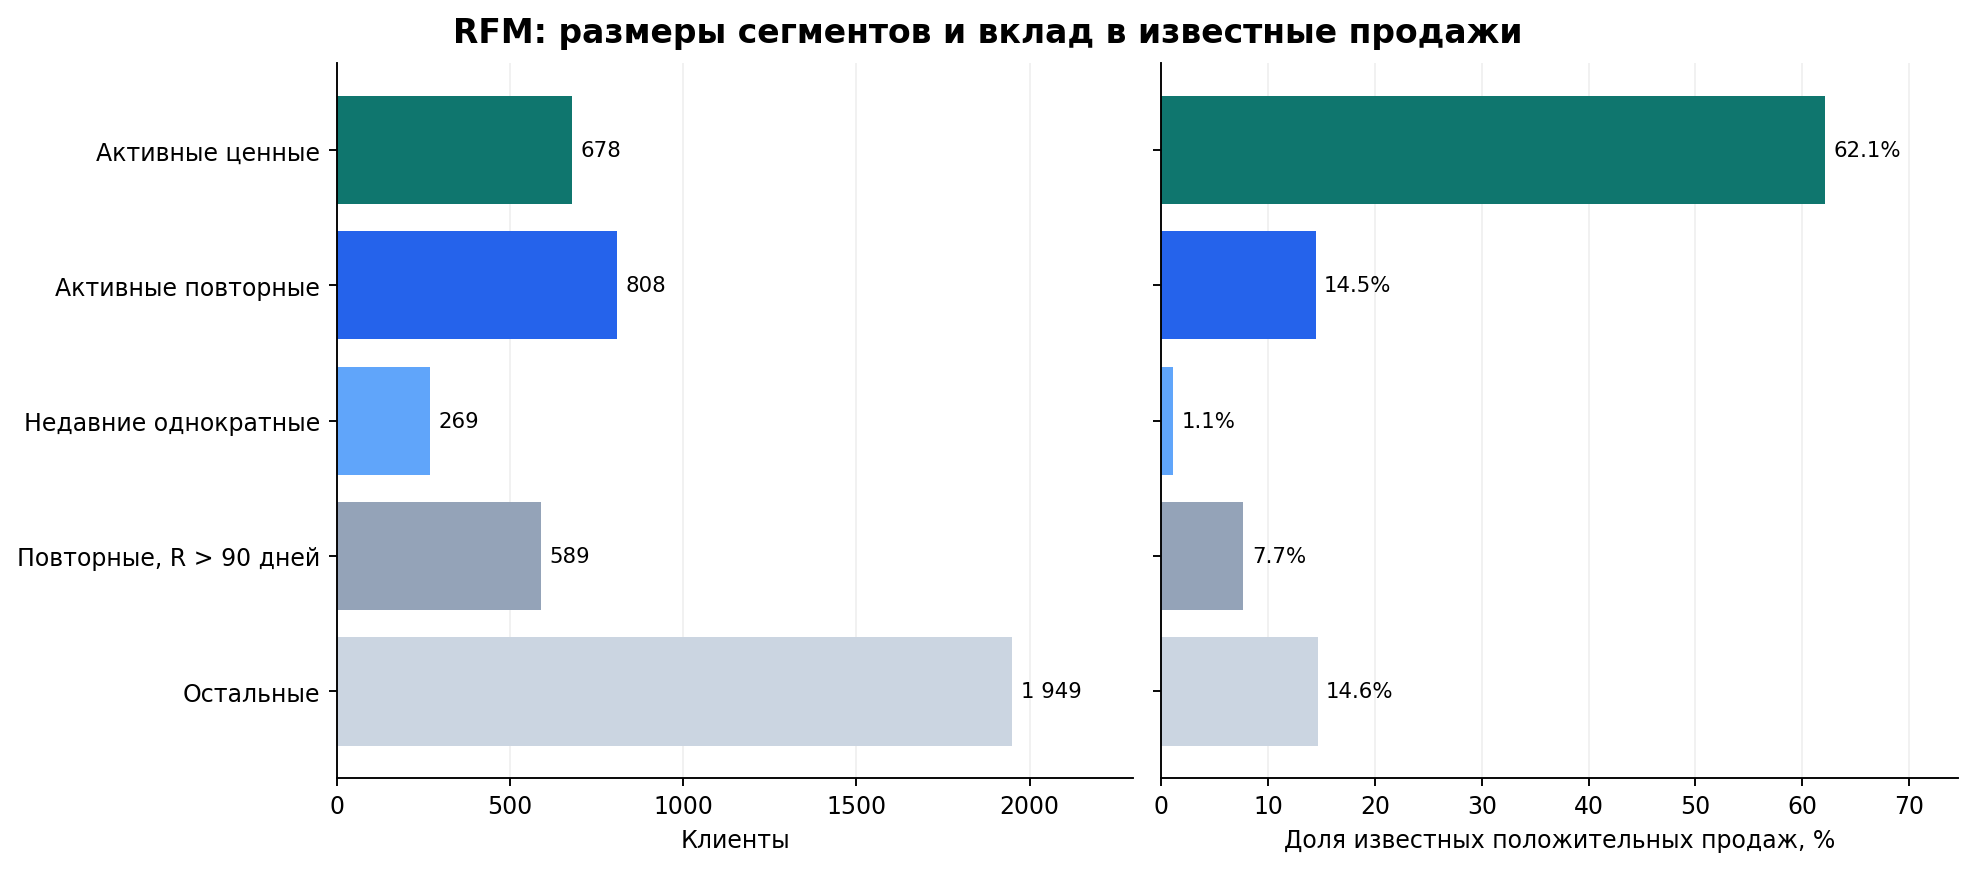

In [16]:
short_labels = ['Активные ценные', 'Активные повторные', 'Недавние однократные',
                'Повторные, R > 90 дней', 'Остальные']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), sharey=True, constrained_layout=True)
y = np.arange(len(SEGMENTS))
segment_colors = [TEAL, BLUE, '#60A5FA', '#94A3B8', '#CBD5E1']
axes[0].barh(y, segment_summary['customers'], color=segment_colors)
axes[1].barh(y, segment_summary['monetary_pct'], color=segment_colors)
axes[0].set_yticks(y, short_labels)
axes[0].invert_yaxis()
axes[0].set_xlabel('Клиенты')
axes[1].set_xlabel('Доля известных положительных продаж, %')
for i, row in enumerate(segment_summary.itertuples()):
    axes[0].text(row.customers + 25, i, f'{row.customers:,}'.replace(',', ' '), va='center', fontsize=9)
    axes[1].text(row.monetary_pct + 0.8, i, f'{row.monetary_pct:.1f}%', va='center', fontsize=9)
axes[0].set_xlim(0, segment_summary['customers'].max() * 1.18)
axes[1].set_xlim(0, segment_summary['monetary_pct'].max() * 1.2)
for ax in axes:
    ax.grid(axis='x', alpha=0.18)
    ax.set_axisbelow(True)
fig.suptitle('RFM: размеры сегментов и вклад в известные продажи', fontsize=14, fontweight='bold')
save_figure(fig, '07_rfm_segments')


## 13. Концентрация продаж

Знаменатель — сумма положительных продаж известных клиентов. Ранжируем по M
по убыванию, при равенстве используем CustomerID. Берём ceil(20% × N), поэтому
доля клиентов может быть чуть больше ровно 20%. Не предполагаем правило 80/20:
измеряем фактическую концентрацию. Это не доля прибыли и не доля всей базы без ID.


Топ 859 из 4293 клиентов: 73.95% известной суммы
Сохранён график: 08_customer_sales_concentration.png


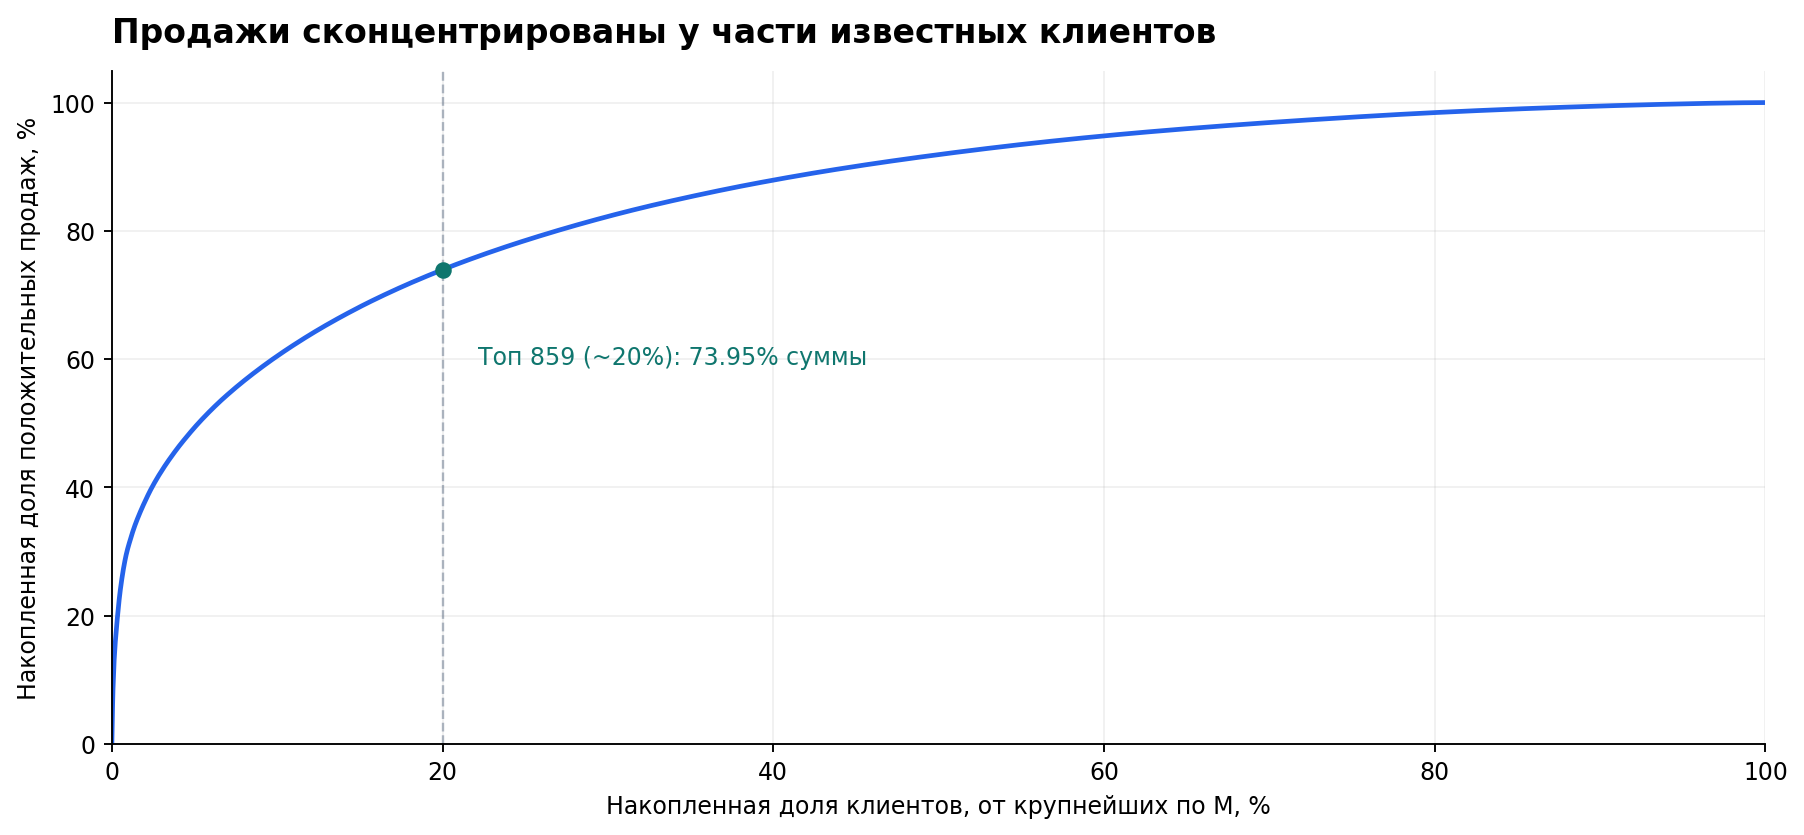

In [17]:
def concentration(rfm_frame):
    ranked = rfm_frame.sort_values(['monetary_gbp', 'customer_id'], ascending=[False, True]).copy()
    count = int(np.ceil(0.2 * len(ranked)))
    total = ranked['monetary_gbp'].sum()
    share = float(100 * ranked.iloc[:count]['monetary_gbp'].sum() / total)
    ranked['cumulative_customers_pct'] = 100 * np.arange(1, len(ranked) + 1) / len(ranked)
    ranked['cumulative_sales_pct'] = 100 * ranked['monetary_gbp'].cumsum() / total
    return ranked, count, share

ranked_customers, top20_count, top20_sales_pct = concentration(rfm)
assert ranked_customers['cumulative_sales_pct'].is_monotonic_increasing
assert np.isclose(ranked_customers.iloc[-1]['cumulative_sales_pct'], 100)
assert top20_count == int(np.ceil(len(rfm) * .2))
ranked_customers.to_csv(TABLES / 'customer_sales_concentration.csv', index=False)
print(f'Топ {top20_count} из {len(rfm)} клиентов: {top20_sales_pct:.2f}% известной суммы')

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
ax.plot(np.r_[0, ranked_customers['cumulative_customers_pct']],
        np.r_[0, ranked_customers['cumulative_sales_pct']], color=BLUE, linewidth=2)
point = ranked_customers.iloc[top20_count - 1]
ax.scatter([point['cumulative_customers_pct']], [point['cumulative_sales_pct']], color=TEAL, zorder=4)
ax.axvline(point['cumulative_customers_pct'], color=GRAY, linestyle='--', linewidth=1, alpha=.5)
ax.annotate(f'Топ {top20_count} (~20%): {top20_sales_pct:.2f}% суммы',
    (point['cumulative_customers_pct'], point['cumulative_sales_pct']),
    xytext=(15, -40), textcoords='offset points', fontsize=10, color=TEAL)
ax.set_xlim(0, 100); ax.set_ylim(0, 105)
ax.set_title('Продажи сконцентрированы у части известных клиентов', fontsize=14, pad=12)
ax.set_xlabel('Накопленная доля клиентов, от крупнейших по M, %')
ax.set_ylabel('Накопленная доля положительных продаж, %')
ax.grid(alpha=.18)
save_figure(fig, '08_customer_sales_concentration')


## 14. Устойчивость сегментов и история отмен

Пересчитываем RFM на данных без точных повторов, включая 75-й перцентиль M,
и сравниваем каждого клиента. Отдельно считаем концентрацию без счёта 541431
с известной отменой. Это диагностический сценарий, не новая основная база.

Суммируем подписанные товарные записи отмен известного клиента внутри окна.
Отношение их абсолютной суммы к gross M — лишь флаг ручной проверки. При
отношении ≥ 50% отмечаем клиента; граница — рабочая эвристика. Это не return rate:
нет надёжного сопоставления со всеми первоначальными заказами, некоторые исходные
покупки могли быть до окна. Отмены не вычитаем автоматически из M и не объявляем
флаг запретом участия в кампании.


In [18]:
# dedup_orders создан в разделе чувствительности этапа 3.
dedup_known = dedup_orders.merge(orders[['invoice_no', 'customer_id']], on='invoice_no', validate='one_to_one')
dedup_known = dedup_known.loc[dedup_known['customer_id'].notna()]
dedup_rfm, dedup_m75 = make_rfm(dedup_known)
segment_comparison = rfm[['customer_id', 'recency_days', 'frequency', 'monetary_gbp', 'segment']].merge(
    dedup_rfm[['customer_id', 'recency_days', 'frequency', 'monetary_gbp', 'segment']],
    on='customer_id', suffixes=('_base', '_dedup'), validate='one_to_one')
assert len(segment_comparison) == len(rfm)
assert np.array_equal(segment_comparison['recency_days_base'], segment_comparison['recency_days_dedup'])
assert np.array_equal(segment_comparison['frequency_base'], segment_comparison['frequency_dedup'])
changed_segments = int(segment_comparison['segment_base'].ne(segment_comparison['segment_dedup']).sum())
_, _, dedup_top20_pct = concentration(dedup_rfm)
without_large_cancelled_rfm, _ = make_rfm(known.loc[known['invoice_no'].ne('541431')])
_, _, concentration_without_541431 = concentration(without_large_cancelled_rfm)
segment_comparison.to_csv(TABLES / 'rfm_duplicate_sensitivity.csv', index=False)

with closing(sqlite3.connect(DB.as_uri() + '?mode=ro', uri=True)) as conn:
    cancellation_by_customer = pd.read_sql_query('''
        SELECT customer_id, COUNT(*) AS cancellation_rows,
               SUM(line_amount_gbp) AS cancellation_signed_gbp
        FROM cancellation_lines
        WHERE in_analysis_window = 1 AND is_excluded_code = 0 AND customer_id IS NOT NULL
        GROUP BY customer_id
    ''', conn)
review = rfm.merge(cancellation_by_customer, on='customer_id', how='left', validate='one_to_one')
review['cancellation_rows'] = review['cancellation_rows'].fillna(0).astype(int)
review['cancellation_signed_gbp'] = review['cancellation_signed_gbp'].fillna(0)
review['cancellation_amount_vs_gross'] = -review['cancellation_signed_gbp'] / review['monetary_gbp']
review['needs_cancellation_review'] = review['cancellation_amount_vs_gross'].ge(0.5)
assert len(review) == len(rfm)
review.to_csv(TABLES / 'rfm_cancellation_review.csv', index=False)
recent_review_count = int(review.loc[review['segment'].eq('Недавние однократные'), 'needs_cancellation_review'].sum())
print('Сменили сегмент без повторов:', changed_segments, '| M75 без повторов:', round(dedup_m75, 2))
print('Топ-20%: основной / без повторов / без 541431:',
      round(top20_sales_pct, 2), round(dedup_top20_pct, 2), round(concentration_without_541431, 2))
print('Флаг проверки отмен:', int(review['needs_cancellation_review'].sum()),
      '| в недавних однократных:', recent_review_count)


Сменили сегмент без повторов: 4 | M75 без повторов: 1569.32
Топ-20%: основной / без повторов / без 541431: 73.95 74.02 73.73
Флаг проверки отмен: 25 | в недавних однократных: 1


## 15. Выводы клиентского анализа и аудитории для проверки

Когортная таблица отвечает на вопрос о возвращении на одинаковом возрасте.
RFM описывает состояние на фиксированную дату. Концентрация показывает вклад
крупных покупателей. Ни один из этих расчётов сам по себе не доказывает эффект
кампании или необходимость скидки. Последний шаг — выбрать гипотезу и дизайн
будущего эксперимента, учесть возможность контакта и стоимость предложения.


In [19]:
stage4 = {
    'snapshot': str(CUTOFF.date()), 'identified_customers': len(rfm),
    'weighted_m1_retention_jan_oct_pct': weighted_m1_pct,
    'repeat_30d_jan_oct_eligible_customers': len(eligible_repeat),
    'repeat_30d_jan_oct_customers': repeat_count, 'repeat_30d_jan_oct_pct': repeat_pct,
    'november_repeat_30d_is_unobserved': bool(pd.isna(repeat_by_cohort.loc['2011-11', 'repeat_30d_pct'])),
    'monetary_p75_gbp': monetary_p75, 'segment_customers': segment_summary['customers'].astype(int).to_dict(),
    'segment_sales_pct': segment_summary['monetary_pct'].to_dict(),
    'top20_customer_count': top20_count, 'top20_known_sales_pct': top20_sales_pct,
    'dedup_changed_segments': changed_segments, 'dedup_monetary_p75_gbp': dedup_m75,
    'dedup_top20_known_sales_pct': dedup_top20_pct,
    'top20_known_sales_pct_without_541431': concentration_without_541431,
    'cancellation_review_customers': int(review['needs_cancellation_review'].sum()),
    'recent_one_order_cancellation_review_customers': recent_review_count,
    'same_first_timestamp_extra_invoices': same_first_extra_invoices,
    'source_sha256': quality['source_sha256'],
    'checks': ['cohort_sql_pandas', 'cohort_future_mask', 'repeat_30d_sql_pandas',
               'rfm_control_totals', 'segment_partition', 'concentration_totals', 'dedup_rfm_comparison'],
}
(ROOT / 'reports/stage4_summary.json').write_text(json.dumps(stage4, ensure_ascii=False, indent=2) + '\n')
segment_table = '\n'.join(f"| {name} | {fmt(row['customers'])} | {fmt(row['monetary_pct'], 2)}% |"
    for name, row in segment_summary.iterrows())
cohort_table = '\n'.join(f"| {month} | {fmt(row['customers'])} | "
    + (f"{fmt(row['retention_m1_pct'], 2)}%" if pd.notna(row['retention_m1_pct']) else 'Не наблюдался') + ' |'
    for month, row in cohort_overview.iterrows())
report = f'''# Retail Customer Analytics — этап 4: удержание, RFM и концентрация

Срез: **01.12.2011**. Окно покупок: **01.12.2010–30.11.2011**, все страны. Клиентская база: {fmt(len(rfm))} известных клиентов. Суммы — положительные товарные продажи до вычета отмен; покрытие клиентскими ID и качество исходника описаны на этапах 2–3.

## 1. Возвращение клиентов на одинаковом возрасте

Retention M1 — доля клиентов когорты с покупкой в следующем календарном месяце. Клиент не обязан покупать каждый месяц до M1/M2. Ненаблюдаемые будущие месяцы остаются пустыми; наблюдаемые без покупок имеют 0.

| Первая наблюдаемая покупка | Размер когорты | Retention M1 |
| --- | ---: | ---: |
{cohort_table}

Взвешенный retention M1 для когорт января–октября — **{fmt(weighted_m1_pct, 2)}%**. Это сумма клиентов с покупкой в M1 / сумма клиентов этих когорт. Среднее процентов когорт без весов не используется. Значения отдельных когорт различаются, но причинную интерпретацию или статистически подтверждённое улучшение этим не устанавливаем.

Декабрь 2010 — первая наблюдаемая когорта; там могут быть клиенты с покупками до начала выгрузки. Её показываем отдельно и исключаем из общего ориентира M1. Ноябрь ещё не имеет наблюдаемого M1.

## 2. Повторный заказ за 30 дней

Среди впервые наблюдаемых клиентов января–октября с полным окном следующий заказ за 30 суток сделали **{fmt(repeat_count)} из {fmt(len(eligible_repeat))} ({fmt(repeat_pct, 2)}%)**. Ноябрьские клиенты не включены: полного окна ещё нет. Их показатель неопределён, а не равен 0%.

Первый заказ + 30 суток должен быть строго раньше 01.12.2011. Следующий заказ имеет другую временную отметку строго позже первой и не позже первого + 30 суток. В базе {fmt(same_first_extra_invoices)} дополнительных счетов с временем первого заказа; одновременные счета не считаются возвращением. SQL и независимый расчёт pandas совпадают по каждому клиенту.

M1 и 30-дневная повторная покупка используют разные окна, поэтому их проценты не должны совпадать. Исторические {fmt(repeat_pct, 2)}% описывают эти когорты и не являются автоматически базовым уровнем будущей кампании среди клиентов, которые всё ещё имеют один заказ на дату среза.

## 3. RFM и возможные аудитории

R — календарные дни от последней покупки до среза, F — различные счета в окне, M — положительные продажи клиента до вычета отмен. 75-й перцентиль M: **{fmt(monetary_p75, 2)} GBP**. Правила сегментов сохранены из этапа 1 и применяются сверху вниз.

| Сегмент | Клиенты | Доля положительных продаж известных клиентов |
| --- | ---: | ---: |
{segment_table}

Правила: активные ценные — R ≤ 30, F ≥ 3, M ≥ M75; активные повторные — R ≤ 60, F ≥ 3; недавние однократные — R ≤ 30, F = 1; давно не покупавшие повторные — R > 90, F ≥ 2; остальные — остаток. Пороги — эвристики, а не установленный цикл покупки. Клиенты входят ровно в один сегмент.

**Основная аудитория для следующей гипотезы:** {fmt(segment_summary.loc['Недавние однократные', 'customers'])} недавних однократных клиентов. Можно проверить напоминание о следующем заказе или подборку товаров. У {fmt(recent_review_count)} клиента из этой группы есть флаг проверки отмен; нужно проверить историю, а не автоматически удалять его из сегмента.

**Дополнительная гипотеза:** реактивация {fmt(segment_summary.loc['Давно не покупавшие повторные', 'customers'])} клиентов с двумя и более заказами и отсутствием покупки более 90 дней. Само отсутствие покупки не доказывает уход. Приоритет между аудиториями и предложение требует данных о доступности контакта, стоимости и возможной выборке.

## 4. Концентрация суммы продаж

Топ **{fmt(top20_count)} клиентов** — ceil(20% × {fmt(len(rfm))}) — дали **{fmt(top20_sales_pct, 2)}%** положительных продаж известной клиентской базы. Ранжирование по M убыванию, при равенстве по CustomerID. Знаменатель не включает продажи без ID. Доля не является долей прибыли или чистой выручки.

Активные ценные клиенты — {fmt(segment_summary.loc['Активные ценные', 'customers'])} человек — дали {fmt(segment_summary.loc['Активные ценные', 'monetary_pct'], 2)}% известной суммы. Это обосновывает внимание к сервису и качеству коммуникаций, но не доказывает пользу скидок.

## 5. Чувствительность и отмены

- Без точных повторов R и F не меняются; сегмент сменили {fmt(changed_segments)} из {fmt(len(rfm))} клиентов. M75 пересчитывается до {fmt(dedup_m75, 2)} GBP. Концентрация топ-20% — {fmt(dedup_top20_pct, 2)}% вместо {fmt(top20_sales_pct, 2)}%.
- Без известного крупного счёта 541431 с отменой концентрация — {fmt(concentration_without_541431, 2)}%. Это отдельный диагностический сценарий, а не полная поправка на отмены.
- Товарные записи отмен суммированы по известным клиентам в том же окне. Для {fmt(stage4['cancellation_review_customers'])} клиентов абсолютная сумма таких записей составляет не менее 50% gross M. Это флаг ручной проверки, не return rate: записи не связаны надёжно со всеми первоначальными заказами, часть первоначальных покупок могла быть раньше окна. Из M ничего автоматически не вычитается.
- Отдельные отменённые крупные продажи остаются существенным ограничением клиентского ранжирования. Аудитория по gross M должна проверяться до запуска кампании.

## Проверки и результаты

Проверены SQL/pandas для активности когорт и 30-дневного исхода каждого клиента; будущие ячейки и M0; контрольные числа RFM; разбиение на сегменты; общая накопленная сумма концентрации; каждый клиент в варианте без повторов. Ноутбук выполнен целиком. Проверка интерфейса Jupyter отдельно не выполнялась.

Файлы: notebooks/02_customer_analytics.ipynb (расширен); sql/05_cohort_activity.sql и 06_repeat_purchase_30d.sql; reports/stage4_summary.json; клиентские и когортные CSV в reports/tables/. Четыре новых графика 05–08 сохранены в PNG/SVG; всего в проекте восемь содержательных графиков.

Следующий этап: итоговый бизнес-отчёт, выбор одной проверяемой гипотезы, дизайн будущего A/B-теста и упаковка проекта. Эффект коммуникации пока не измерен, рост продаж не обещается.

Источник: Chen, D. (2015). Online Retail. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33. CC BY 4.0. Источник и SHA-256 — в data/raw/source_manifest.json.
'''
(ROOT / 'reports/stage4_findings.md').write_text(report, encoding='utf-8')
print(f'Retention M1: {weighted_m1_pct:.2f}%; повтор за 30 дней: {repeat_pct:.2f}%')
print(f'Топ-20%: {top20_sales_pct:.2f}%; сменили RFM-сегмент без повторов: {changed_segments}')
print('Сохранён отчёт этапа 4. Далее — бизнес-рекомендации и дизайн эксперимента.')


Retention M1: 19.73%; повтор за 30 дней: 17.73%
Топ-20%: 73.95%; сменили RFM-сегмент без повторов: 4
Сохранён отчёт этапа 4. Далее — бизнес-рекомендации и дизайн эксперимента.


## Следующий шаг

Две аудитории для обсуждения — недавние однократные и давно не покупавшие
повторные клиенты. Перед кампанией нужно проверить контактность и историю отмен.
Будущий эксперимент измеряет результат после назначения коммуникации; это
другое окно и другой знаменатель, чем историческая повторная покупка после первого заказа.
